# Практическая работа 2. Свёрточные нейронные сети: обнаружение объектов

## Детекция средств индивидуальной защиты с помощью YOLO26

**Выполнил(а):** _________________________  (Фамилия И. О.)

**Группа:** _____________

**Преподаватель:** _____________

---

Цель работы — изучить обнаружение объектов с помощью свёрточных нейронных сетей на
примере архитектуры YOLO26. Используется размеченный датасет Construction Site Safety
с сайта [Roboflow Universe](https://universe.roboflow.com/roboflow-universe-projects/construction-site-safety):
изображения строительных площадок с разметкой средств защиты (каски, жилеты, маски) и
других объектов.

В работе обучаются три версии YOLO26 (nano, small, medium), они сравниваются между
собой, лучшая модель тестируется на новых изображениях и сопоставляется со второй
архитектурой — Faster R-CNN. Качество оценивается на проверочной и тестовой выборках по
метрикам Precision, Recall, mAP и IoU.

## 1. Установка библиотек и импорт

In [1]:
!pip install -q -U ultralytics torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 62.7 MB/s eta 0:00:00


In [2]:
import os
import glob
import random

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from PIL import Image

import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
SEED = 42
MODELS = ["yolo26n", "yolo26s", "yolo26m"]
EPOCHS = 20
IMGSZ = 640
BATCH = 16
FRACTION = 1.0
FRCNN_EPOCHS = 5
FRCNN_BATCH = 4
FRCNN_MAX_TRAIN = 800
FRCNN_MAX_TEST = None

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__)
print("устройство:", device)

torch: 2.11.0+cu128
устройство: cuda


## 2. Загрузка датасета

Датасет заранее скачан с [Roboflow Universe](https://universe.roboflow.com/roboflow-universe-projects/construction-site-safety) в формате YOLOv8. Архив загружается с компьютера и распаковывается.

In [5]:
from google.colab import files
import zipfile

uploaded = files.upload()
archive = next(iter(uploaded))

DATA_DIR = "construction_site_safety"
with zipfile.ZipFile(archive) as z:
    z.extractall(DATA_DIR)

for root, dirs, names in os.walk(DATA_DIR):
    if "data.yaml" in names:
        DATA_DIR = root
        break

DATA_YAML = os.path.join(DATA_DIR, "data.yaml")
meta = yaml.safe_load(open(DATA_YAML))
meta["path"] = os.path.abspath(DATA_DIR)
meta["train"] = "train/images"
meta["val"] = "valid/images"
meta["test"] = "test/images"
yaml.safe_dump(meta, open(DATA_YAML, "w"))
print("каталог данных:", DATA_DIR)

Saving construction-site-safety.zip to construction-site-safety.zip
каталог данных: construction_site_safety


## 3. Описание датасета

Классы, размеры выборок и примеры изображений с разметкой.

In [6]:
meta = yaml.safe_load(open(DATA_YAML))
class_names = meta["names"]
num_classes = len(class_names)
print("классов:", num_classes)
print(class_names)
for split in ["train", "valid", "test"]:
    n = len(glob.glob(os.path.join(DATA_DIR, split, "images", "*")))
    print(f"{split}: {n} изображений")

классов: 10
['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
train: 2603 изображений
valid: 114 изображений
test: 82 изображений


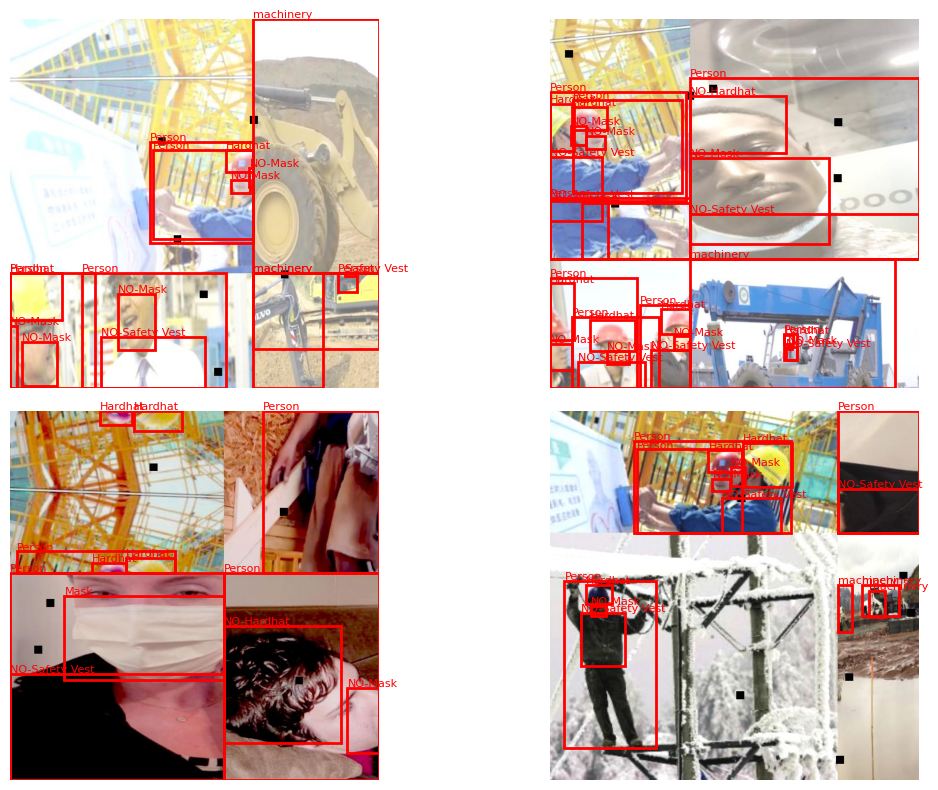

In [7]:
def draw_boxes(img_path, label_path):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    plt.imshow(img)
    ax = plt.gca()
    if os.path.exists(label_path):
        for line in open(label_path):
            cls, cx, cy, bw, bh = map(float, line.split())
            x = (cx - bw / 2) * w
            y = (cy - bh / 2) * h
            rect = plt.Rectangle((x, y), bw * w, bh * h, fill=False, color="red", linewidth=2)
            ax.add_patch(rect)
            ax.text(x, y - 2, class_names[int(cls)], color="red", fontsize=8)
    plt.axis("off")


train_imgs = sorted(glob.glob(os.path.join(DATA_DIR, "train", "images", "*")))
plt.figure(figsize=(12, 8))
for i in range(min(4, len(train_imgs))):
    plt.subplot(2, 2, i + 1)
    img_path = train_imgs[i]
    label_path = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"
    draw_boxes(img_path, label_path)
plt.tight_layout()
plt.show()

## 4. Подбор гиперпараметров

Гиперпараметры выбраны по характеру задачи и ограничениям бесплатного GPU. Размер
изображения 640 на 640 — стандартный для YOLO и достаточный, чтобы различать мелкие
объекты вроде касок и масок. Размер батча 16 укладывается в память T4. Число эпох 20
даёт модели сойтись на этом датасете и при этом укладывается во время сессии.
Оптимизатор и скорость обучения оставлены по умолчанию (YOLO сам подбирает их под
датасет).

Главный перебираемый гиперпараметр — размер самой модели. Ниже обучаются три версии
YOLO26 (nano, small, medium) в одинаковых условиях, и по проверочной и тестовой
выборкам выбирается лучшая. Это и есть подбор оптимальной конфигурации: мы смотрим, как
размер сети влияет на качество и стоимость обучения.

In [8]:
runs_info = {}
comparison = []
for name in MODELS:
    m = YOLO(f"{name}.pt")
    res = m.train(data=DATA_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
                  fraction=FRACTION, seed=SEED, project="runs", name=name, exist_ok=True)
    save_dir = str(res.save_dir)
    best = YOLO(os.path.join(save_dir, "weights", "best.pt"))
    mv = best.val(data=DATA_YAML, split="test")
    n_params = sum(p.numel() for p in best.model.parameters()) / 1e6
    runs_info[name] = {"save_dir": save_dir, "model": best}
    comparison.append({"модель": name, "параметры, млн": round(n_params, 2),
                       "mAP50": round(mv.box.map50, 4), "mAP50-95": round(mv.box.map, 4),
                       "precision": round(mv.box.mp, 4), "recall": round(mv.box.mr, 4)})

df_yolo = pd.DataFrame(comparison)
best_name = df_yolo.loc[df_yolo["mAP50-95"].idxmax(), "модель"]
best_model = runs_info[best_name]["model"]
best_dir = runs_info[best_name]["save_dir"]
print(df_yolo.to_string(index=False))
print("лучшая версия по mAP50-95:", best_name)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Construction-Site-Safety-27/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

## 5. Метрики лучшей модели на валидации и тесте

In [9]:
val_metrics = best_model.val(data=DATA_YAML, split="val")
print("Валидационная выборка:")
print(f"  mAP50: {val_metrics.box.map50:.4f}  mAP50-95: {val_metrics.box.map:.4f}  "
      f"Precision: {val_metrics.box.mp:.4f}  Recall: {val_metrics.box.mr:.4f}")

test_metrics = best_model.val(data=DATA_YAML, split="test")
print("Тестовая выборка:")
print(f"  mAP50: {test_metrics.box.map50:.4f}  mAP50-95: {test_metrics.box.map:.4f}  "
      f"Precision: {test_metrics.box.mp:.4f}  Recall: {test_metrics.box.mr:.4f}")

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2072.6±741.1 MB/s, size: 46.8 KB)
val: Scanning /content/Construction-Site-Safety-27/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 47.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.4it/s 5.9s
                   all        114        697      0.897      0.752      0.834      0.522
               Hardhat         42         79      0.945      0.823      0.899      0.558
                  Mask         19         21      0.972      0.857      0.946      0.639
            NO-Hardhat         37         69       0.93      0.576      0.744      0.411
               NO-Mask         44         74      0.872      0.689      0.744      0.351
        NO-Safety Vest         56        106       0.82      0.689      0.751       0.43
                Perso

## 6. Графики обучения

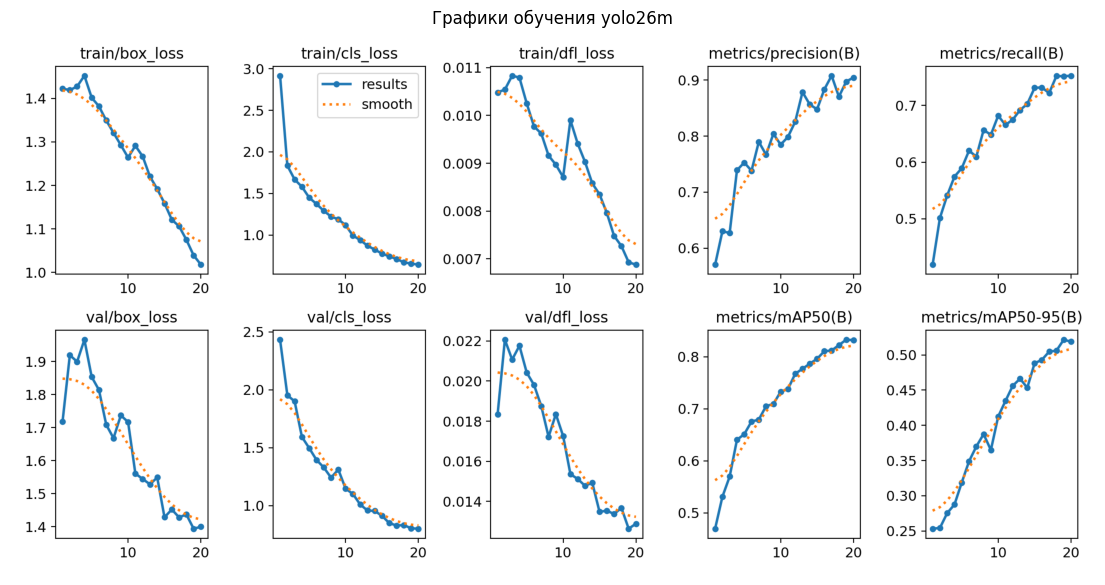

In [10]:
results_png = os.path.join(best_dir, "results.png")
if os.path.exists(results_png):
    plt.figure(figsize=(14, 8))
    plt.imshow(Image.open(results_png))
    plt.axis("off")
    plt.title(f"Графики обучения {best_name}")
    plt.show()

## 7. Анализ ошибок

Матрица ошибок показывает, какие классы путаются между собой и где модель ошибается.

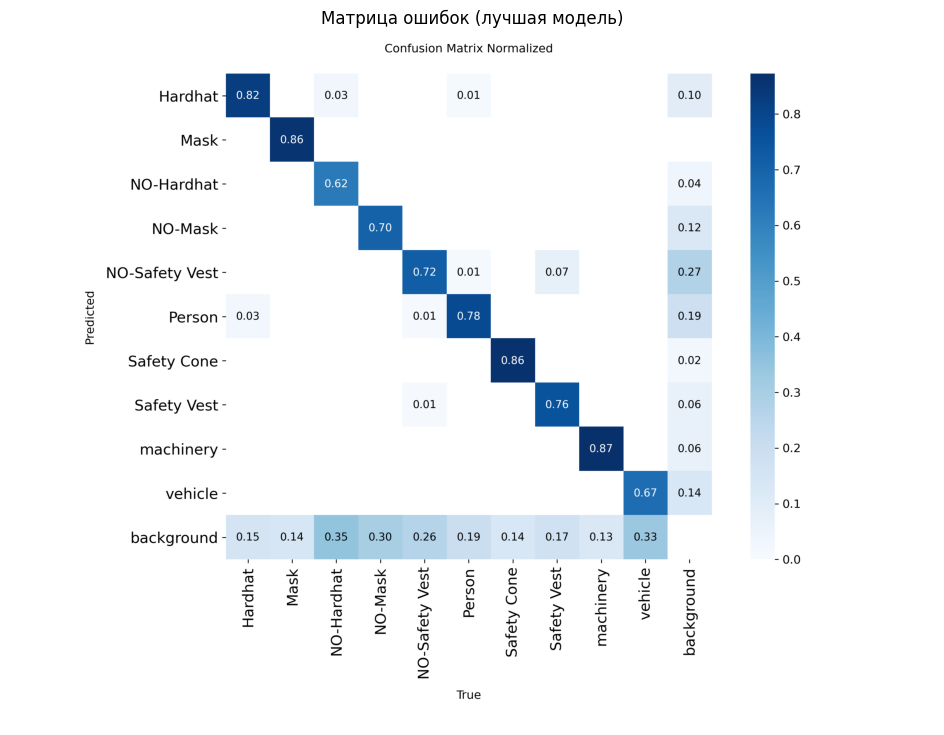

In [11]:
cm_png = os.path.join(best_dir, "confusion_matrix_normalized.png")
if not os.path.exists(cm_png):
    cm_png = os.path.join(best_dir, "confusion_matrix.png")
if os.path.exists(cm_png):
    plt.figure(figsize=(12, 9))
    plt.imshow(Image.open(cm_png))
    plt.axis("off")
    plt.title("Матрица ошибок (лучшая модель)")
    plt.show()

## 8. Тестирование на новых изображениях

Запускаем лучшую модель на изображениях из тестовой выборки и визуализируем найденные объекты.

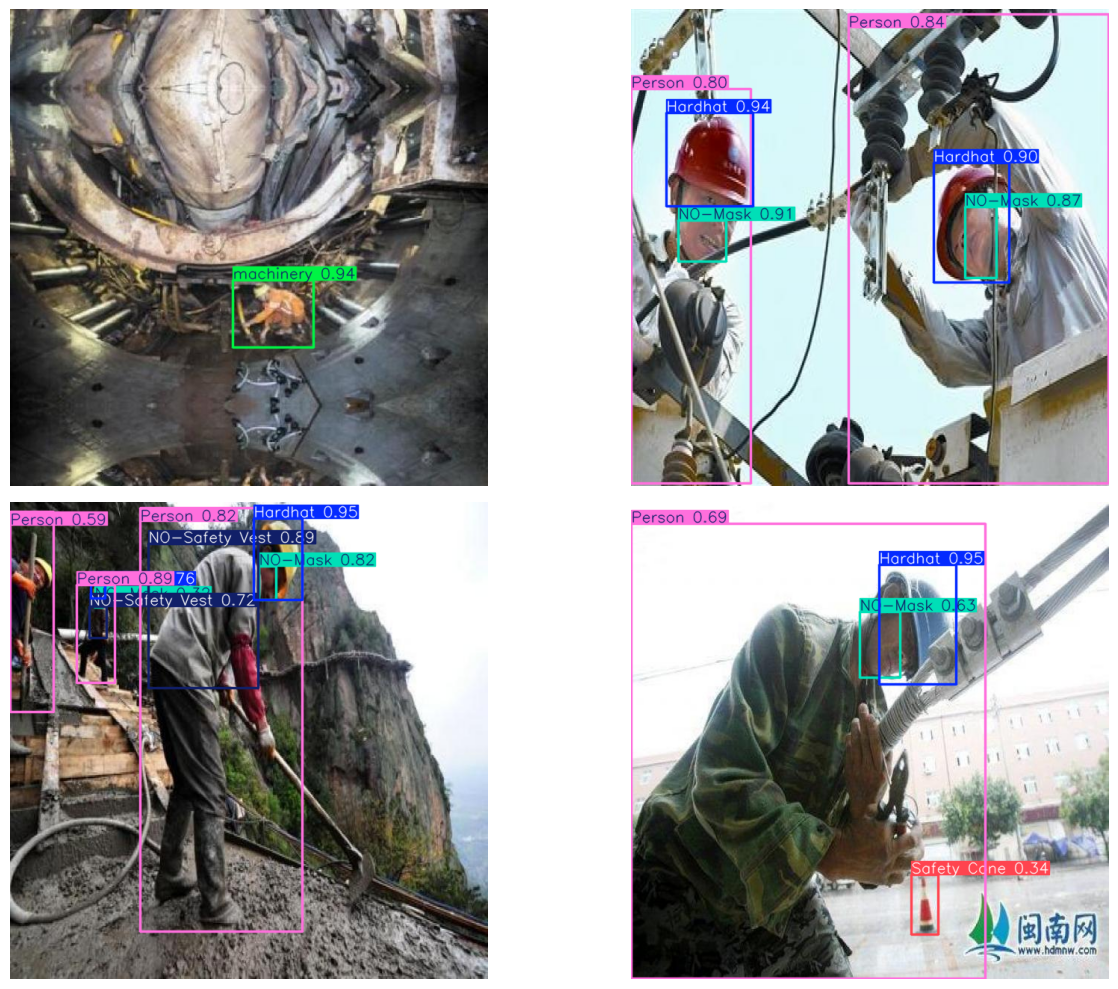

In [12]:
test_imgs = sorted(glob.glob(os.path.join(DATA_DIR, "test", "images", "*")))[:4]
preds = best_model.predict(test_imgs, imgsz=IMGSZ, conf=0.25, verbose=False)
plt.figure(figsize=(14, 10))
for i, r in enumerate(preds):
    plt.subplot(2, 2, i + 1)
    plt.imshow(r.plot()[:, :, ::-1])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Сравнение со второй моделью — Faster R-CNN

Обучаем двухэтапный детектор Faster R-CNN на части тех же данных и сравниваем с YOLO.

In [13]:
from torchvision.transforms.functional import to_tensor
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader, Subset


class YoloDetectionDataset(Dataset):
    def __init__(self, root, split):
        self.img_files = sorted(glob.glob(os.path.join(root, split, "images", "*")))

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        label_path = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"
        boxes, labels = [], []
        if os.path.exists(label_path):
            for line in open(label_path):
                cls, cx, cy, bw, bh = map(float, line.split())
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                x2 = (cx + bw / 2) * w
                y2 = (cy + bh / 2) * h
                if x2 > x1 and y2 > y1:
                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls) + 1)
        if boxes:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        return to_tensor(img), {"boxes": boxes, "labels": labels}


def collate_fn(batch):
    return tuple(zip(*batch))


train_ds = YoloDetectionDataset(DATA_DIR, "train")
test_ds = YoloDetectionDataset(DATA_DIR, "test")
if FRCNN_MAX_TRAIN is not None:
    train_ds = Subset(train_ds, list(range(min(FRCNN_MAX_TRAIN, len(train_ds)))))
if FRCNN_MAX_TEST is not None:
    test_ds = Subset(test_ds, list(range(min(FRCNN_MAX_TEST, len(test_ds)))))

gen = torch.Generator()
gen.manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=FRCNN_BATCH, shuffle=True,
                          collate_fn=collate_fn, generator=gen)
test_loader = DataLoader(test_ds, batch_size=FRCNN_BATCH, shuffle=False, collate_fn=collate_fn)
print("train/test для Faster R-CNN:", len(train_ds), len(test_ds))

train/test для Faster R-CNN: 800 82


In [14]:
torch.manual_seed(SEED)
frcnn = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = frcnn.roi_heads.box_predictor.cls_score.in_features
frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)
frcnn = frcnn.to(device)
optimizer = torch.optim.SGD([p for p in frcnn.parameters() if p.requires_grad],
                            lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

for epoch in range(1, FRCNN_EPOCHS + 1):
    frcnn.train()
    total = 0.0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = frcnn(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    scheduler.step()
    print(f"эпоха {epoch}/{FRCNN_EPOCHS} loss={total / len(train_loader):.4f}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 171MB/s]


эпоха 1/5 loss=1.5749
эпоха 2/5 loss=1.1191
эпоха 3/5 loss=0.9526
эпоха 4/5 loss=0.7707
эпоха 5/5 loss=0.7254


In [15]:
from torchmetrics.detection import MeanAveragePrecision

metric = MeanAveragePrecision()
frcnn.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        preds = frcnn(images)
        preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
        metric.update(preds, targets)
frcnn_res = metric.compute()
print(f"Faster R-CNN mAP50: {float(frcnn_res['map_50']):.4f}")
print(f"Faster R-CNN mAP50-95: {float(frcnn_res['map']):.4f}")

Faster R-CNN mAP50: 0.6108
Faster R-CNN mAP50-95: 0.2832


In [16]:
best_row = df_yolo.loc[df_yolo["mAP50-95"].idxmax()]
summary = pd.DataFrame([
    {"модель": f"YOLO26 ({best_name})", "mAP50": best_row["mAP50"], "mAP50-95": best_row["mAP50-95"]},
    {"модель": "Faster R-CNN", "mAP50": round(float(frcnn_res["map_50"]), 4),
     "mAP50-95": round(float(frcnn_res["map"]), 4)},
])
print(summary.to_string(index=False))

          модель  mAP50  mAP50-95
YOLO26 (yolo26m) 0.7643    0.4810
    Faster R-CNN 0.6108    0.2832


## 10. Дополнительная метрика IoU

Средний по нескольким изображениям лучший IoU между предсказанными и истинными рамками.

In [17]:
from torchvision.ops import box_iou

frcnn.eval()
ious = []
with torch.no_grad():
    for i in range(min(20, len(test_ds))):
        img_t, target = test_ds[i]
        pred = frcnn([img_t.to(device)])[0]
        pb = pred["boxes"].cpu()
        gb = target["boxes"]
        if len(pb) and len(gb):
            ious.append(box_iou(pb, gb).max(dim=0).values.mean().item())

if ious:
    print(f"средний лучший IoU по {len(ious)} изображениям: {np.mean(ious):.4f}")
else:
    print("предсказаний для расчёта IoU не получено")

средний лучший IoU по 18 изображениям: 0.6579


## Выводы и ответы на контрольные вопросы

### Как работает YOLO

YOLO решает задачу обнаружения за один проход сети. Изображение делится на сетку, и
сеть сразу предсказывает координаты рамок, вероятность наличия объекта и класс. В
отличие от двухэтапных детекторов, которые сначала ищут области-кандидаты, а затем их
классифицируют, YOLO делает всё одновременно, поэтому работает быстро и подходит для
реального времени. Версия YOLO26 использует свёрточную основу для выделения признаков
и облегчённую голову детекции.

### Сравнение версий nano, small и medium

Версии отличаются размером сети. Nano самая лёгкая и быстрая, но её точность обычно
ниже. Medium тяжелее по числу параметров и времени обучения, зато даёт более высокое
mAP. Small занимает промежуточное положение. По таблице сравнения видно соотношение
качества и размера; стоит учитывать, что тестовая выборка небольшая, поэтому разброс
метрик заметный и порядок nano-small-medium может выполняться нестрого. Выбор версии —
это компромисс между скоростью и качеством.

### Метрики Precision, Recall, mAP и IoU

Precision показывает долю верных срабатываний среди всех предсказанных рамок, Recall —
долю найденных объектов среди всех размеченных. Среднее значение точности mAP считается
по площади под кривой precision-recall и усредняется по классам. mAP50 использует порог
совпадения рамок IoU 0,5, а mAP50-95 усредняет метрику по порогам от 0,5 до 0,95 и
поэтому строже. IoU — это отношение площади пересечения предсказанной и истинной рамок
к площади их объединения; именно по нему решают, считать ли предсказание верным.

### Сравнение YOLO и Faster R-CNN

Faster R-CNN — двухэтапный детектор: сначала отдельная подсеть предлагает области, затем
они уточняются и классифицируются. Он обычно точен, но медленнее YOLO из-за двух этапов.
YOLO обрабатывает изображение целиком за один проход, что даёт выигрыш в скорости. В
этой работе Faster R-CNN обучался меньше и на части данных, поэтому его mAP ниже — по
таблице сравнения видно текущее соотношение, а при равных условиях обучения разрыв
сократился бы. Выбор между подходами зависит от того, что важнее в задаче — скорость
или максимальная точность.